In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
train = pd.read_csv("../data/raw/ciciot2023/train/train.csv")

validation = pd.read_csv("../data/raw/ciciot2023/validation/validation.csv")

test = pd.read_csv("../data/raw/ciciot2023/test/test.csv")

In [3]:
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (5491971, 47)
Validation: (1176851, 47)
Test: (1176851, 47)


In [4]:
train.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,9627.00,374.0,1457.00,883.202217,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.0,54.00,54.000000,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.99,0.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,572.51,54.0,59.51,54.753345,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,6216.00,592.0,592.00,592.000000,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.0,54.00,54.000000,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [5]:
train.columns

Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='str')

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 5491971 entries, 0 to 5491970
Data columns (total 47 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   Header_Length    float64
 2   Protocol Type    float64
 3   Duration         float64
 4   Rate             float64
 5   Srate            float64
 6   Drate            float64
 7   fin_flag_number  float64
 8   syn_flag_number  float64
 9   rst_flag_number  float64
 10  psh_flag_number  float64
 11  ack_flag_number  float64
 12  ece_flag_number  float64
 13  cwr_flag_number  float64
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  HTTP             float64
 20  HTTPS            float64
 21  DNS              float64
 22  Telnet           float64
 23  SMTP             float64
 24  SSH              float64
 25  IRC              float64
 26  TCP              float64
 27  UDP              float6

In [7]:
train.isnull().sum()

flow_duration      0
Header_Length      0
Protocol Type      0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
urg_count          0
rst_count          0
HTTP               0
HTTPS              0
DNS                0
Telnet             0
SMTP               0
SSH                0
IRC                0
TCP                0
UDP                0
DHCP               0
ARP                0
ICMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                0
Tot size           0
IAT                0
Number             0
Magnitue           0
Radius             0
Covariance         0
Variance           0
Weight             0
label              0
dtype: int64

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
flow_duration,5491971.0,5.657345e+00,2.749157e+02,0.000000,0.000000e+00,0.000000e+00,1.050286e-01,9.943576e+04
Header_Length,5491971.0,7.687147e+04,4.615005e+05,0.000000,5.400000e+01,5.400000e+01,3.001300e+02,9.890105e+06
Protocol Type,5491971.0,9.066457e+00,8.943837e+00,0.000000,6.000000e+00,6.000000e+00,1.444000e+01,4.700000e+01
Duration,5491971.0,6.636141e+01,1.406518e+01,0.000000,6.400000e+01,6.400000e+01,6.400000e+01,2.550000e+02
Rate,5491971.0,9.049942e+03,9.986400e+04,0.000000,2.093860e+00,1.578598e+01,1.178755e+02,8.388608e+06
Srate,5491971.0,9.049942e+03,9.986400e+04,0.000000,2.093860e+00,1.578598e+01,1.178755e+02,8.388608e+06
Drate,5491971.0,3.229612e-06,1.848825e-03,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.679210e+00
fin_flag_number,5491971.0,8.650082e-02,2.811022e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
syn_flag_number,5491971.0,2.071142e-01,4.052381e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
rst_flag_number,5491971.0,9.042418e-02,2.867885e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [9]:
train.columns.tolist()

['flow_duration',
 'Header_Length',
 'Protocol Type',
 'Duration',
 'Rate',
 'Srate',
 'Drate',
 'fin_flag_number',
 'syn_flag_number',
 'rst_flag_number',
 'psh_flag_number',
 'ack_flag_number',
 'ece_flag_number',
 'cwr_flag_number',
 'ack_count',
 'syn_count',
 'fin_count',
 'urg_count',
 'rst_count',
 'HTTP',
 'HTTPS',
 'DNS',
 'Telnet',
 'SMTP',
 'SSH',
 'IRC',
 'TCP',
 'UDP',
 'DHCP',
 'ARP',
 'ICMP',
 'IPv',
 'LLC',
 'Tot sum',
 'Min',
 'Max',
 'AVG',
 'Std',
 'Tot size',
 'IAT',
 'Number',
 'Magnitue',
 'Radius',
 'Covariance',
 'Variance',
 'Weight',
 'label']

In [10]:
train.isnull().sum().sort_values(ascending=False).head(10)

flow_duration      0
Header_Length      0
Protocol Type      0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
dtype: int64

In [11]:
train.duplicated().sum()

np.int64(134565)

In [12]:
train["label"].value_counts()

label
DDoS-ICMP_Flood            848088
DDoS-UDP_Flood             637558
DDoS-TCP_Flood             528499
DDoS-PSHACK_Flood          481254
DDoS-SYN_Flood             478653
DDoS-RSTFINFlood           475441
DDoS-SynonymousIP_Flood    422083
DoS-UDP_Flood              390422
DoS-TCP_Flood              314174
DoS-SYN_Flood              237573
BenignTraffic              129538
Mirai-greeth_flood         116133
Mirai-udpplain             104814
Mirai-greip_flood           88821
DDoS-ICMP_Fragmentation     53046
MITM-ArpSpoofing            36316
DDoS-UDP_Fragmentation      34169
DDoS-ACK_Fragmentation      33581
DNS_Spoofing                21214
Recon-HostDiscovery         15737
Recon-OSScan                11587
Recon-PortScan               9648
DoS-HTTP_Flood               8487
VulnerabilityScan            4396
DDoS-HTTP_Flood              3371
DDoS-SlowLoris               2757
DictionaryBruteForce         1541
BrowserHijacking              665
CommandInjection              620
SqlInjec

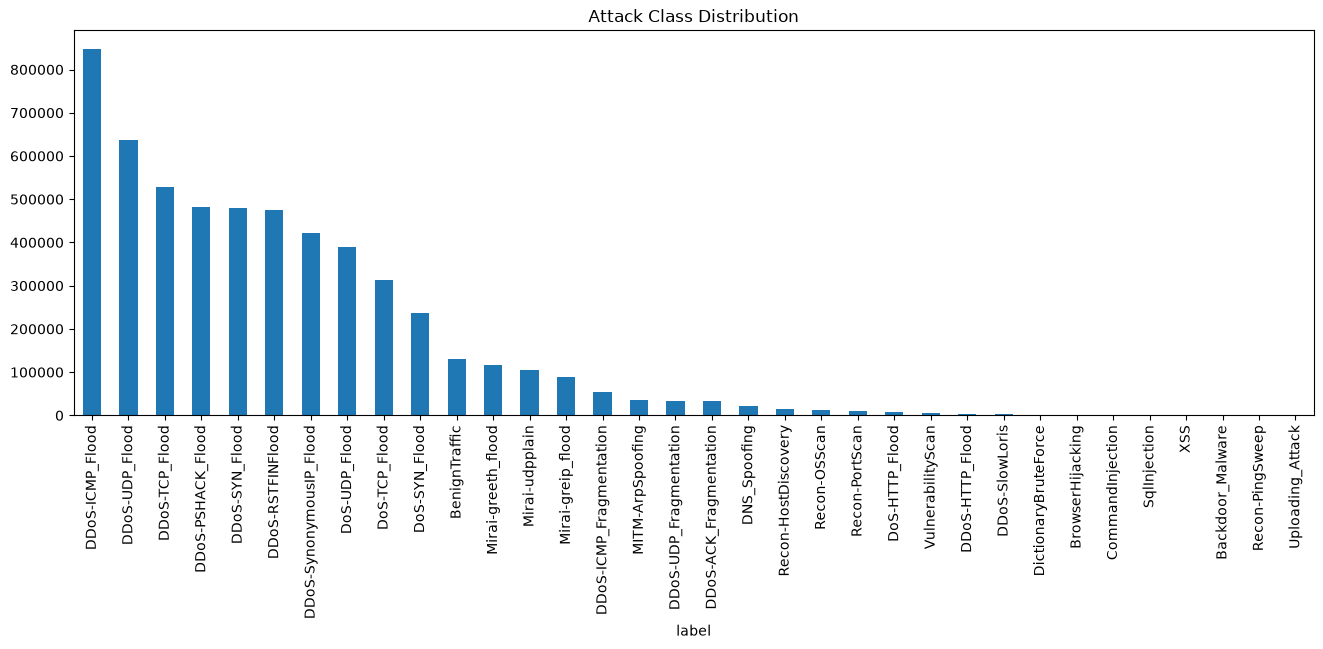

In [13]:
train["label"].value_counts().plot(
    kind="bar",
    figsize=(16,5),
    title="Attack Class Distribution"
)

plt.xticks(rotation=90)
plt.show()

In [14]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
flow_duration,5491971.0,5.657345e+00,2.749157e+02,0.000000,0.000000e+00,0.000000e+00,1.050286e-01,9.943576e+04
Header_Length,5491971.0,7.687147e+04,4.615005e+05,0.000000,5.400000e+01,5.400000e+01,3.001300e+02,9.890105e+06
Protocol Type,5491971.0,9.066457e+00,8.943837e+00,0.000000,6.000000e+00,6.000000e+00,1.444000e+01,4.700000e+01
Duration,5491971.0,6.636141e+01,1.406518e+01,0.000000,6.400000e+01,6.400000e+01,6.400000e+01,2.550000e+02
Rate,5491971.0,9.049942e+03,9.986400e+04,0.000000,2.093860e+00,1.578598e+01,1.178755e+02,8.388608e+06
Srate,5491971.0,9.049942e+03,9.986400e+04,0.000000,2.093860e+00,1.578598e+01,1.178755e+02,8.388608e+06
Drate,5491971.0,3.229612e-06,1.848825e-03,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.679210e+00
fin_flag_number,5491971.0,8.650082e-02,2.811022e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
syn_flag_number,5491971.0,2.071142e-01,4.052381e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
rst_flag_number,5491971.0,9.042418e-02,2.867885e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


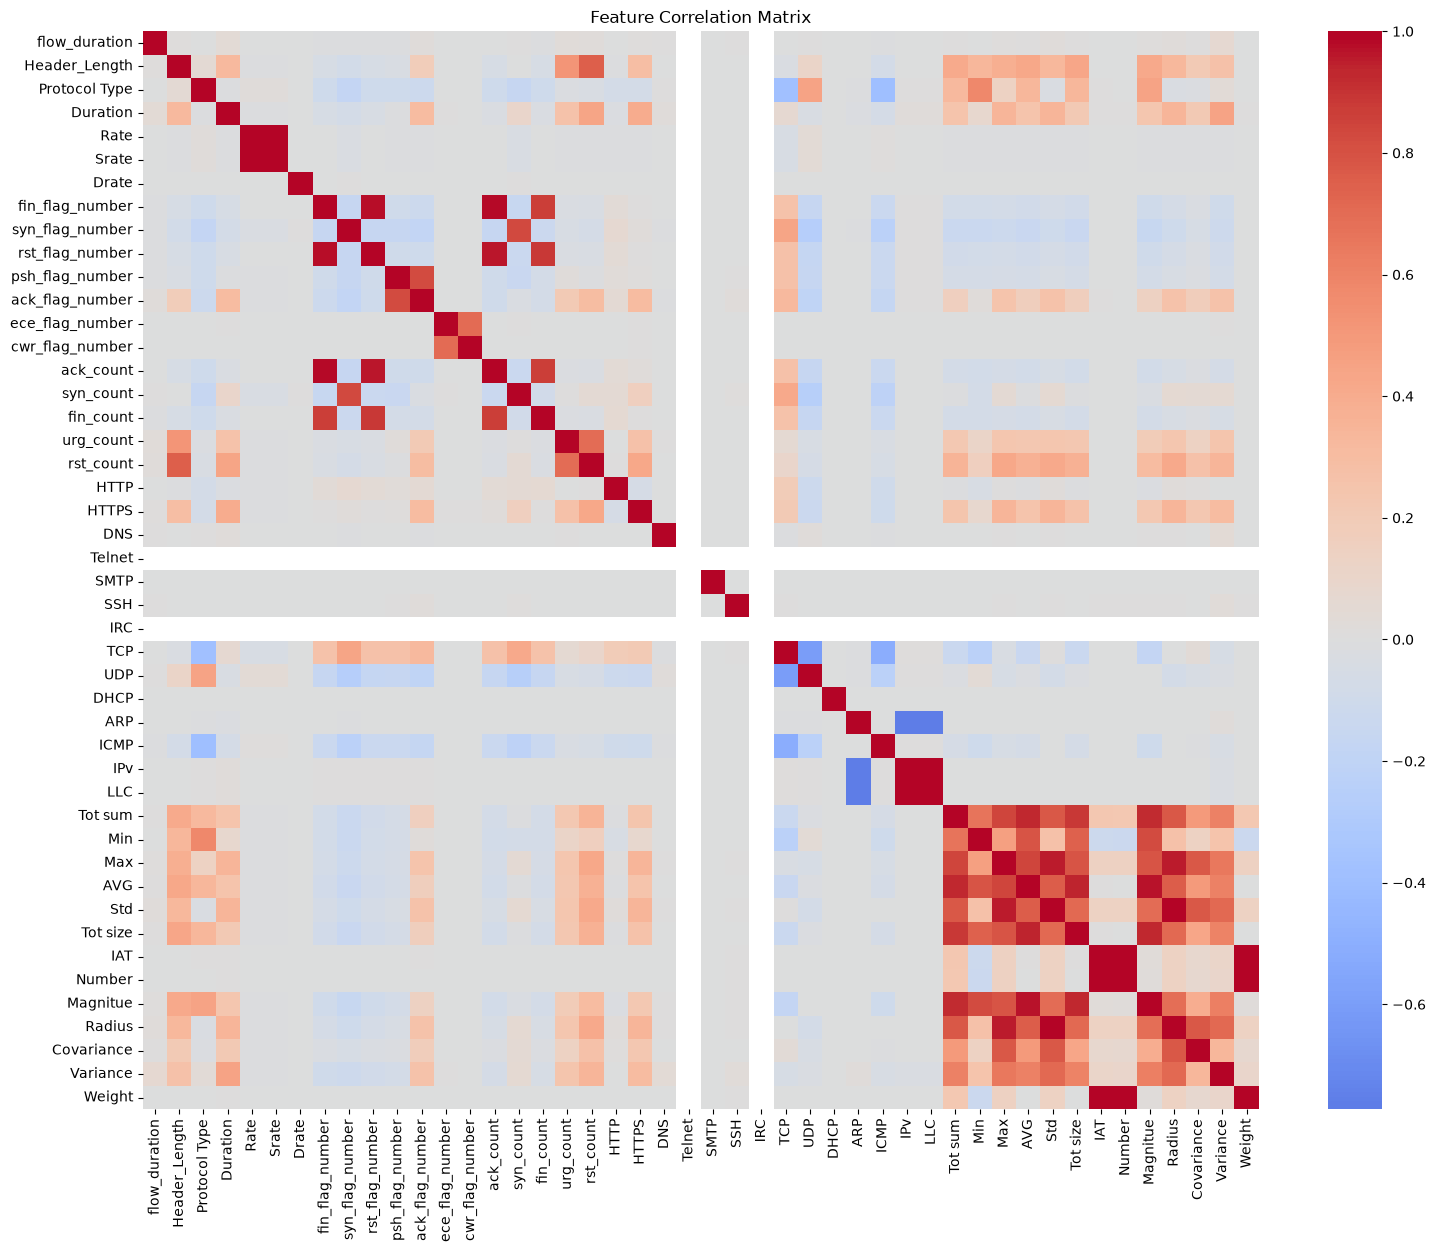

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,14))

sns.heatmap(
    train.drop(columns="label").corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()